In [1]:
### The following code was used for DQN and DDQN for the modified environment (increased wind) ###

In [2]:
#IMPORTS
import gymnasium as gym
import ale_py

import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm
from collections import deque


In [3]:
device = torch.device('cuda' if torch.cuda.is_available()else 'cpu')

In [7]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 128)
        self.fc2 = nn.Linear(128,128)
        self.fc3 = nn.Linear(128, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [5]:
class DQNAGENT():

  def __init__(self,game,target_update_freq,memory,learning_rate,batch,mode):

    self.game = game
    self.target_update = target_update_freq
    self.memorysize = memory
    self.batch_size = batch
    self.learning_rate = learning_rate
    self.mode = mode
    
    self.env = gym.make(game,enable_wind = True,wind_power = 15.0,gravity = -10.0,turbulence_power = 1.5)
    self.state_space = self.env.observation_space.shape[0]
    self.num_actions = self.env.action_space.n
    
    self.memory = deque(maxlen = memory)
    self.epsilon = 1
    self.epsilon_min = 0.001
    self.epsilon_decay = 0.992
    
    self.q1 = DQN(self.state_space,self.num_actions).to(device)
    self.q2 = DQN(self.state_space,self.num_actions).to(device)
    self.q2.load_state_dict(self.q1.state_dict())
    self.q1.train()
    self.q2.eval()
    self.optimizer = optim.Adam(self.q1.parameters(), lr=self.learning_rate)

    self.counter = 0
    self.episode = 0
    self.reward_episode = []


  def greedypolicy(self,state):

    if np.random.rand() <= self.epsilon:

        return np.random.randint(self.num_actions)
    else:
    
        with torch.no_grad():

         q_values = self.q1(state)
         move = torch.argmax(q_values).item()

        return move

  def experiencereplay(self):
    if len(self.memory) < self.batch_size:
        return

    batch = random.sample(self.memory, self.batch_size)
    state_batch, action_batch, reward_batch, next_state_batch, terminal_batch = zip(*batch)

    state_batch = torch.cat(state_batch,dim = 0).to(device)
    action_batch = torch.LongTensor(action_batch).unsqueeze(1).to(device)
    reward_batch = torch.FloatTensor(reward_batch).to(device)
    next_state_batch = torch.cat(next_state_batch).to(device)
    terminal_batch = torch.FloatTensor(terminal_batch).to(device)


    yvals = self.q1(state_batch).gather(1, action_batch).squeeze()

    # Compute target Q-values using the target network
    with torch.no_grad():

        if self.mode == 'DQN':

          target_values = self.q2(next_state_batch).max(1)[0]

        elif self.mode == 'DDQN':

          target_states = self.q2(next_state_batch)

          next_action = torch.argmax(self.q1(next_state_batch), dim=1)
          target_values = target_states.gather(1, next_action.unsqueeze(1)).squeeze(1)
          
        yhatvals = reward_batch + 0.99 * target_values * (1- terminal_batch)


    loss = F.mse_loss(yvals, yhatvals)
    self.optimizer.zero_grad()
    loss.backward()
    self.optimizer.step()

  def train(self,episode_num):

     for i in tqdm(range(0,episode_num)):

       done = False
       reward_total = 0
    
       current_state,info = self.env.reset()
       current_state_torch = torch.from_numpy(current_state).float().unsqueeze(0).to(device)
      
       while done == False:
        
        action = self.greedypolicy(current_state_torch)
        next_state, reward, terminated, truncated, info = self.env.step(action)
        
        done = terminated or truncated
        next_state_torch = torch.from_numpy(next_state).float().unsqueeze(0).to(device)

        self.memory.append((current_state_torch, action, reward, next_state_torch, done))
        self.experiencereplay()

        current_state_torch = next_state_torch
        reward_total += reward
        self.counter +=1

       self.episode += 1
       self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
       self.reward_episode.append(reward_total)


       if self.episode % self.target_update == 0:
            self.q2.load_state_dict(self.q1.state_dict())
              
       print(i,reward_total)


  def reward_plot(self,window,reward_episode):
    moving_average = []
    for i in range(1,window):

      moving_average.append(np.mean(reward_episode[:i]))

    for i in range(window,len(reward_episode)+1):
       average_window = reward_episode[i-window:i]
       moving_average.append(np.mean(average_window))
    
    self.moving_average = moving_average

    plt.plot(np.linspace(0,len(reward_episode)-1,len(reward_episode)),reward_episode, alpha = 0.6,label='Episodic Reward', color = 'blue')
    plt.plot(np.linspace(0,len(reward_episode)-1,len(reward_episode)),np.array(moving_average), label = 'Rolling Average',color = 'orange')
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
    plt.rcParams['axes.facecolor'] = 'lavender'
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.title(str(self.game) + "-" +str(self.mode))
    plt.legend()
    plt.show()

  def multi_agent(self,number_agents,number_train):
    rewards = np.zeros(number_train)
    for i in range(0,number_agents):
     self.train(number_train)
     rewards += np.array(self.reward_episode)
     self.__init__(self.game, self.target_update,self.memorysize,self.learning_rate,self.batch_size,self.mode)
    
    self.multiagent_reward = list(rewards/number_agents)

  




In [ ]:
### Training a DQN agent ###

#This is all for the modified environment with added wind
#Initialise agent using following structure DQNAGENT(environment,memory buffer size, learning rate,batchsize,version of DQN)

#Example for DQN
  #agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DQN') # These parameters were used for the results
  #agent1.train(2000) trains agent for 2000 episodes
  #agent1.reward_plot(100,agent1.reward_episode) #plots the agents result with its moving average
  #agent1.moving_average gives the moving average as a list



#Example for DDQN
  #agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DDQN') for final argument use 'DDQN
  #agent1.train(2000) trains agent for 2000 episodes
  #agent1.reward_plot(100,agent1.reward_episode) plots the agents result with its moving average
  #agent1.moving_average gives the moving average as a list 

In [8]:
agent1 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DQN')
agent1.train(2000)

  0%|          | 0/2000 [00:00<?, ?it/s]

0 -157.3898750423664
1 -183.8654316916738
2 -508.2880861379234
3 -135.18502651693237
4 -288.6224467247471
5 -212.3566885186188
6 -277.7663698600571
7 -514.0267337245236
8 -209.61545705934697
9 -76.366990953611
10 -312.5605796830082
11 -117.79493949069072
12 -122.56446134509784
13 -374.6313002241692
14 -132.51092295934592
15 -417.17616413072926
16 -132.54174041617637
17 -202.7145258846773
18 -229.33880451687108
19 -534.8916475063093
20 -219.10019842066973
21 -321.120480481999
22 -359.27798674615576
23 -309.52186086000603
24 -96.62150413376793
25 -133.35179146750733
26 -344.59696765229063
27 -46.80773664342729
28 -408.5983625464685
29 -317.3630636721538
30 -358.64380266991657
31 -274.6108888058636
32 -279.90225299643373
33 -299.8847823796659
34 -264.62423132302763
35 -226.31431581659353
36 -143.5106097765238
37 -388.75601137607117
38 -83.75387289675551
39 -202.2861222421617
40 -135.82449662921442
41 -243.05804117141412
42 -185.21674621575067
43 -137.93178152836464
44 -274.3975347356877
4

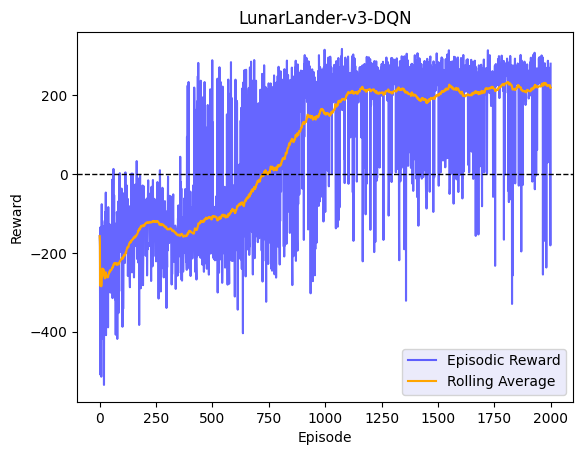

In [9]:
agent1.reward_plot(100,agent1.reward_episode)

In [10]:
agent2 = DQNAGENT("LunarLander-v3",6,100000,0.0003,64,'DDQN')
agent2.train(2000)

  0%|          | 0/2000 [00:00<?, ?it/s]

0 -79.02387737060725
1 -226.30267063013315
2 -334.6034166669365
3 -443.24896178806785
4 -165.8960412992932
5 -296.4108669661909
6 -479.9419469897089
7 -412.21350105038164
8 -355.67343260998075
9 -332.88981739022097
10 -151.5616123392178
11 -374.0353456334541
12 -89.09446382526009
13 -304.42973839157366
14 -207.4296286208767
15 -69.9045992629542
16 -201.22348604954368
17 -62.43504791541567
18 -350.4275327470875
19 -131.2861301877703
20 -20.570908315203468
21 -226.91887119577189
22 -151.87300182645708
23 -209.08333978937694
24 -319.7447588497195
25 -401.5620010556686
26 -319.7775471501652
27 -254.19703737585132
28 -34.8645054144353
29 -67.1240587726247
30 35.16991027863776
31 -301.45495254774517
32 -267.9825980895967
33 -48.84593052005907
34 -227.1406545890697
35 -210.46399384737217
36 -450.70791516637587
37 -124.24707363249874
38 -170.02032755653016
39 -173.07286647673575
40 -134.7703580192802
41 -332.89453317723303
42 -264.00517763389894
43 -140.71671663708446
44 -302.1557569273553
45 

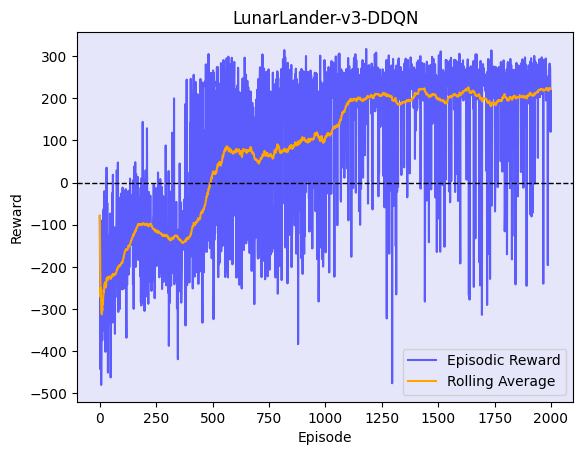

In [12]:
agent2.reward_plot(100,agent2.reward_episode)